# Data Understanding

## 1. Gambaran Umum Dataset

Dataset yang digunakan terdiri dari 3 file utama:

| Nama File        | Deskripsi                                                                              |
| ---------------- | -------------------------------------------------------------------------------------- |
| `train.csv`      | Dataset utama yang berisi data historis untuk proses pelatihan model machine learning. |
| `test.csv`       | Dataset yang digunakan untuk proses pengujian/prediksi model.                          |
| `submission.csv` | Contoh format hasil prediksi yang akan digunakan saat proses submission.               |

Dataset ini berisi data penyebaran COVID-19 berdasarkan wilayah dan tanggal tertentu. Informasi utama yang tersedia meliputi jumlah kasus terkonfirmasi (`ConfirmedCases`) dan jumlah kematian (`Fatalities`).

---

# 2. Struktur Dataset

## 2.1 Dataset Train

Jumlah data pada dataset train:

* Jumlah baris: **17.892**
* Jumlah kolom: **8**

### Fitur/Variabel pada `train.csv`

| Nama Kolom       | Tipe Data     | Deskripsi                                   |
| ---------------- | ------------- | ------------------------------------------- |
| `Id`             | Integer       | ID unik untuk setiap data.                  |
| `Province/State` | Object/String | Nama provinsi atau state dari suatu negara. |
| `Country/Region` | Object/String | Nama negara atau wilayah.                   |
| `Lat`            | Float         | Koordinat latitude lokasi.                  |
| `Long`           | Float         | Koordinat longitude lokasi.                 |
| `Date`           | Object/Date   | Tanggal pencatatan data COVID-19.           |
| `ConfirmedCases` | Float         | Jumlah kasus COVID-19 yang terkonfirmasi.   |
| `Fatalities`     | Float         | Jumlah kematian akibat COVID-19.            |

---

## 2.2 Dataset Test

Jumlah data pada dataset test:

* Jumlah baris: **12.212**
* Jumlah kolom: **6**

### Fitur/Variabel pada `test.csv`

| Nama Kolom       | Tipe Data     | Deskripsi                    |
| ---------------- | ------------- | ---------------------------- |
| `ForecastId`     | Integer       | ID unik untuk data prediksi. |
| `Province/State` | Object/String | Nama provinsi atau state.    |
| `Country/Region` | Object/String | Nama negara atau wilayah.    |
| `Lat`            | Float         | Koordinat latitude lokasi.   |
| `Long`           | Float         | Koordinat longitude lokasi.  |
| `Date`           | Object/Date   | Tanggal prediksi.            |

---

## 2.3 Dataset Submission

Jumlah data pada dataset submission:

* Jumlah baris: **12.212**
* Jumlah kolom: **3**

### Fitur/Variabel pada `submission.csv`

| Nama Kolom       | Tipe Data | Deskripsi                                    |
| ---------------- | --------- | -------------------------------------------- |
| `ForecastId`     | Integer   | ID prediksi yang sesuai dengan dataset test. |
| `ConfirmedCases` | Float     | Hasil prediksi jumlah kasus terkonfirmasi.   |
| `Fatalities`     | Float     | Hasil prediksi jumlah kematian.              |

---

# Data Collection

Tahap Data Collection dilakukan untuk menggabungkan seluruh dataset yang tersedia menjadi satu dataset utama yang akan digunakan pada tahap analisis selanjutnya.
Pada tahap ini dilakukan beberapa proses:
1. Load dataset
2. Menggabungkan dataset `test.csv` dengan `submission.csv`
3. Menggabungkan hasil merge dengan dataset `train.csv`

In [501]:
# =========================================
# Data Collection
# =========================================

# Import library
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)





# =========================================
# 1. Load Dataset
# =========================================

# Membaca dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('submission.csv')


# =========================================
# 2. Merge Dataset Test dan Submission
# =========================================

# Menggabungkan dataset test dan submission
# berdasarkan kolom ForecastId

test_submission_merge = pd.merge(
    test,
    submission,
    on='ForecastId',
    how='left'
)


# =========================================
# 3. Merge Hasil Merge dengan Dataset Train
# =========================================

# Menggabungkan dataset train dengan
# hasil merge sebelumnya

full_data = pd.concat(
    [train, test_submission_merge],
    ignore_index=True,
    sort=False
)


# =========================================
# Menampilkan Hasil Dataset Gabungan
# =========================================

print("Ukuran Dataset Gabungan :", full_data.shape)

full_data.head()

Ukuran Dataset Gabungan : (30104, 9)


,Id,Province/State,Country/Region,Lat,Long,Date,ConfirmedCases,Fatalities,ForecastId
0,1.0,NaN,Afghanistan,33.0,65.0,2020-01-22,0.0,0.0,NaN
1,2.0,NaN,Afghanistan,33.0,65.0,2020-01-23,0.0,0.0,NaN
2,3.0,NaN,Afghanistan,33.0,65.0,2020-01-24,0.0,0.0,NaN
3,4.0,NaN,Afghanistan,33.0,65.0,2020-01-25,0.0,0.0,NaN
4,5.0,NaN,Afghanistan,33.0,65.0,2020-01-26,0.0,0.0,NaN


### Insight

- Dataset `train` digunakan sebagai data pelatihan model.
- Dataset `test` digunakan sebagai data prediksi.
- Dataset `submission` digunakan sebagai format hasil prediksi.

Dataset `test` dan `submission` digabungkan menggunakan kolom `ForecastId`.

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami kondisi data secara lebih mendalam sebelum masuk ke tahap preprocessing.

Pada tahap ini dilakukan beberapa analisis, yaitu:

1. Melihat informasi dataset dan statistik deskriptif
2. Mengecek missing value
3. Mengecek outlier
4. Mengecek data duplicate
5. Mengidentifikasi jenis atribut
6. Melakukan analisis korelasi antar atribut numerik
7. Mengidentifikasi fitur yang perlu dilakukan encoding

Tujuan dari tahap ini adalah untuk mengetahui permasalahan pada data yang nantinya akan ditangani pada tahap preprocessing.

Tahap ini dilakukan untuk melihat struktur dataset, tipe data, serta statistik deskriptif dari setiap atribut numerik.

In [502]:
# =========================================
# Cek Informasi Dataset
# =========================================

print(full_data.info())


# =========================================
# Statistik Deskriptif
# =========================================

full_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30104 entries, 0 to 30103
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              17892 non-null  float64
 1   Province/State  13780 non-null  str    
 2   Country/Region  30104 non-null  str    
 3   Lat             30104 non-null  float64
 4   Long            30104 non-null  float64
 5   Date            30104 non-null  str    
 6   ConfirmedCases  30104 non-null  float64
 7   Fatalities      30104 non-null  float64
 8   ForecastId      12212 non-null  float64
dtypes: float64(6), str(3)
memory usage: 2.1 MB
None


,Id,Lat,Long,ConfirmedCases,Fatalities,ForecastId
count,17892.000000,30104.000000,30104.000000,30104.000000,30104.000000,12212.000000
mean,13191.500000,26.287693,4.766191,193.689377,7.522721,6106.500000
std,7624.675152,22.934832,79.922355,2732.637812,134.515972,3525.445078
min,1.000000,-41.454500,-157.498300,0.000000,0.000000,1.000000
25%,6596.250000,13.145425,-71.516375,0.000000,0.000000,3053.750000
50%,13191.500000,32.985550,9.775000,1.000000,0.000000,6106.500000
75%,19786.750000,42.501575,64.688975,1.000000,1.000000,9159.250000
max,26382.000000,71.706900,174.886000,69176.000000,6820.000000,12212.000000


### Insight

Dari hasil informasi dataset dapat diketahui:

- jumlah data pada setiap kolom
- tipe data masing-masing atribut
- kemungkinan adanya missing value

Sedangkan statistik deskriptif digunakan untuk melihat:

- rata-rata data
- persebaran data
- nilai minimum dan maksimum
- indikasi adanya outlier

Tahap ini dilakukan untuk mengecek apakah terdapat data yang kosong atau missing value pada dataset.

In [503]:
# =========================================
# Cek Missing Value
# =========================================

missing_values = full_data.isnull().sum()

missing_values

Id                12212
Province/State    16324
Country/Region        0
Lat                   0
Long                  0
Date                  0
ConfirmedCases        0
Fatalities            0
ForecastId        17892
dtype: int64

### Insight

Hasil pengecekan missing value digunakan untuk mengetahui kolom mana saja yang memiliki data kosong.

Missing value nantinya akan ditangani pada tahap preprocessing.

Tahap ini dilakukan untuk mendeteksi adanya outlier pada atribut numerik menggunakan metode IQR (Interquartile Range).

In [504]:
# =========================================
# Cek Outlier Menggunakan IQR
# =========================================

numerical_columns = [
    'Lat',
    'Long',
    'ConfirmedCases',
    'Fatalities'
]

for col in numerical_columns:

    Q1 = full_data[col].quantile(0.25)
    Q3 = full_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = full_data[
        (full_data[col] < lower_bound) |
        (full_data[col] > upper_bound)
    ]

    print(f"{col} : {len(outliers)} outliers")

Lat : 1060 outliers
Long : 0 outliers
ConfirmedCases : 5649 outliers
Fatalities : 1204 outliers


### Insight

Outlier merupakan data yang memiliki nilai sangat jauh dari distribusi normal data.

Keberadaan outlier dapat mempengaruhi performa model machine learning sehingga perlu dipertimbangkan penanganannya pada tahap preprocessing.

Tahap ini dilakukan untuk mengecek apakah terdapat data duplikat pada dataset.

In [505]:
# =========================================
# Cek Data Duplicate
# =========================================

duplicate_data = full_data.duplicated().sum()

print("Jumlah Data Duplicate :", duplicate_data)

Jumlah Data Duplicate : 0


### Insight

Data duplicate dapat menyebabkan bias pada model machine learning.

Jika ditemukan data duplicate maka akan dilakukan penanganan pada tahap preprocessing.

Tahap ini dilakukan untuk mengelompokkan atribut berdasarkan jenis datanya.

In [506]:
# =========================================
# Identifikasi Jenis Atribut
# =========================================

string_attributes = [
    'Province/State',
    'Country/Region'
]

numerical_attributes = [
    'Lat',
    'Long',
    'ConfirmedCases',
    'Fatalities'
]

date_attributes = [
    'Date'
]


print("Atribut String :")
print(string_attributes)

print("\nAtribut Numerik :")
print(numerical_attributes)

print("\nAtribut Tanggal :")
print(date_attributes)

Atribut String :
['Province/State', 'Country/Region']

Atribut Numerik :
['Lat', 'Long', 'ConfirmedCases', 'Fatalities']

Atribut Tanggal :
['Date']


### Insight

Berdasarkan hasil identifikasi atribut:

- atribut string perlu dipertimbangkan untuk proses encoding
- atribut numerik dapat digunakan langsung untuk analisis statistik dan model machine learning
- atribut tanggal dapat dilakukan ekstraksi fitur waktu pada tahap preprocessing

Tahap ini dilakukan untuk melihat hubungan antar atribut numerik terutama terhadap atribut Fatalities.

In [507]:
# =========================================
# Analisis Korelasi
# =========================================

correlation = full_data[
    ['Lat', 'Long', 'ConfirmedCases', 'Fatalities']
].corr()

correlation

,Lat,Long,ConfirmedCases,Fatalities
Lat,1.000000,-0.223177,0.025906,0.020303
Long,-0.223177,1.000000,0.061685,0.043519
ConfirmedCases,0.025906,0.061685,1.000000,0.927734
Fatalities,0.020303,0.043519,0.927734,1.000000


### Insight

Analisis korelasi digunakan untuk mengetahui hubungan antar atribut numerik.

Nilai korelasi mendekati:
- 1  : hubungan positif kuat
- -1 : hubungan negatif kuat
- 0  : tidak memiliki hubungan

Korelasi yang tinggi antara ConfirmedCases dan Fatalities dapat menunjukkan bahwa peningkatan jumlah kasus terkonfirmasi berpengaruh terhadap jumlah kematian.

Tahap ini dilakukan untuk mengidentifikasi kolom kategorikal yang perlu dilakukan encoding sebelum digunakan pada model machine learning.

In [508]:
# =========================================
# Identifikasi Kolom Kategorikal
# =========================================

categorical_columns = full_data.select_dtypes(
    include=['object']
).columns

print("Kolom yang perlu dilakukan encoding :")
print(categorical_columns)

Kolom yang perlu dilakukan encoding :
Index(['Province/State', 'Country/Region', 'Date'], dtype='str')


C:\Users\Acer Suport\AppData\Local\Temp\ipykernel_28324\3509982475.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = full_data.select_dtypes(


### Insight

Kolom dengan tipe data object tidak dapat langsung digunakan pada model machine learning.

Kolom tersebut perlu dilakukan encoding pada tahap preprocessing agar dapat diubah menjadi bentuk numerik.

# Data Preprocessing
Tahap Data Preprocessing dilakukan untuk membersihkan dan mempersiapkan data sebelum digunakan pada proses pembuatan model machine learning.

Berdasarkan hasil Exploratory Data Analysis (EDA), ditemukan beberapa permasalahan pada dataset, yaitu:

1. Terdapat missing value pada beberapa kolom
2. Terdapat outlier pada atribut numerik
3. Terdapat atribut kategorikal yang belum dapat digunakan oleh model machine learning
4. Kolom tanggal masih berbentuk data mentah dan perlu dilakukan ekstraksi fitur
5. Kemungkinan terdapat data duplicate

Pada tahap preprocessing ini akan dilakukan beberapa penanganan, yaitu:

1. Menangani missing value
2. Menghapus data duplicate
3. Menangani outlier
4. Melakukan ekstraksi fitur tanggal
5. Melakukan encoding pada atribut kategorikal
6. Memastikan dataset siap digunakan untuk proses modeling

Tujuan dari tahap preprocessing adalah untuk meningkatkan kualitas data sehingga model machine learning dapat bekerja lebih optimal.

In [509]:
# =========================================
# Menangani Missing Value
# =========================================

# Mengisi missing value pada kolom kategorikal
# dengan nilai 'Unknown'

full_data['Province/State'] = full_data[
    'Province/State'
].fillna('Unknown')


# Mengecek kembali missing value
full_data.isnull().sum()

Id                12212
Province/State        0
Country/Region        0
Lat                   0
Long                  0
Date                  0
ConfirmedCases        0
Fatalities            0
ForecastId        17892
dtype: int64

Pada kolom `ForecastId` masih terdapat missing value karena kolom tersebut hanya dimiliki oleh dataset test dan submission.

Sedangkan dataset train tidak memiliki kolom tersebut sehingga saat proses penggabungan data, baris yang berasal dari dataset train memiliki nilai kosong pada kolom `ForecastId`.

Karena kolom `ForecastId` hanya berfungsi sebagai identifier dan tidak digunakan dalam proses modeling, maka kolom ini dapat dihapus.hal ini berlaku juga pada kolom `Id`

In [510]:
# =========================================
# Menghapus Kolom ForecastId
# =========================================

full_data = full_data.drop(
    columns=['ForecastId','Id']
)

full_data.isnull().sum()


Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
ConfirmedCases    0
Fatalities        0
dtype: int64

In [511]:
# =========================================
# Menghapus Duplicate Data
# =========================================

full_data = full_data.drop_duplicates()


# Mengecek kembali duplicate data
full_data.duplicated().sum()

np.int64(0)

In [512]:
# =========================================
# Penanganan Outlier Menggunakan IQR
# =========================================

numerical_columns = [
    'Lat',
    'Long',
    'ConfirmedCases',
    'Fatalities'
]

for col in numerical_columns:

    Q1 = full_data[col].quantile(0.25)
    Q3 = full_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    full_data = full_data[
        (full_data[col] >= lower_bound) &
        (full_data[col] <= upper_bound)
    ]


# Melihat ukuran dataset setelah outlier dihapus
full_data.shape

(23633, 7)

In [513]:
# =========================================
# Konversi Kolom Date ke Format Datetime
# =========================================

full_data['Date'] = pd.to_datetime(
    full_data['Date']
)

In [514]:
# =========================================
# Ekstraksi Fitur Tanggal
# =========================================

full_data['Year'] = full_data['Date'].dt.year
full_data['Month'] = full_data['Date'].dt.month
full_data['Day'] = full_data['Date'].dt.day


# Menampilkan hasil
full_data.head()

,Province/State,Country/Region,Lat,Long,Date,ConfirmedCases,Fatalities,Year,Month,Day
0,Unknown,Afghanistan,33.0,65.0,2020-01-22,0.0,0.0,2020,1,22
1,Unknown,Afghanistan,33.0,65.0,2020-01-23,0.0,0.0,2020,1,23
2,Unknown,Afghanistan,33.0,65.0,2020-01-24,0.0,0.0,2020,1,24
3,Unknown,Afghanistan,33.0,65.0,2020-01-25,0.0,0.0,2020,1,25
4,Unknown,Afghanistan,33.0,65.0,2020-01-26,0.0,0.0,2020,1,26


In [515]:
# =========================================
# Import Label Encoder
# =========================================

from sklearn.preprocessing import LabelEncoder

In [516]:
# =========================================
# Encoding Kolom Kategorikal
# =========================================

label_encoder = LabelEncoder()


full_data['Province/State'] = label_encoder.fit_transform(
    full_data['Province/State']
)

full_data['Country/Region'] = label_encoder.fit_transform(
    full_data['Country/Region']
)


# Menampilkan hasil encoding
full_data.head()

,Province/State,Country/Region,Lat,Long,Date,ConfirmedCases,Fatalities,Year,Month,Day
0,111,0,33.0,65.0,2020-01-22,0.0,0.0,2020,1,22
1,111,0,33.0,65.0,2020-01-23,0.0,0.0,2020,1,23
2,111,0,33.0,65.0,2020-01-24,0.0,0.0,2020,1,24
3,111,0,33.0,65.0,2020-01-25,0.0,0.0,2020,1,25
4,111,0,33.0,65.0,2020-01-26,0.0,0.0,2020,1,26


In [517]:
# =========================================
# Menghapus Kolom Date
# =========================================

full_data = full_data.drop(
    columns=['Date']
)


# Melihat dataset akhir
full_data.head()

,Province/State,Country/Region,Lat,Long,ConfirmedCases,Fatalities,Year,Month,Day
0,111,0,33.0,65.0,0.0,0.0,2020,1,22
1,111,0,33.0,65.0,0.0,0.0,2020,1,23
2,111,0,33.0,65.0,0.0,0.0,2020,1,24
3,111,0,33.0,65.0,0.0,0.0,2020,1,25
4,111,0,33.0,65.0,0.0,0.0,2020,1,26


In [518]:
# =========================================
# Informasi Dataset Setelah Preprocessing
# =========================================

full_data.info()

<class 'pandas.DataFrame'>
Index: 23633 entries, 0 to 30103
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  23633 non-null  int64  
 1   Country/Region  23633 non-null  int64  
 2   Lat             23633 non-null  float64
 3   Long            23633 non-null  float64
 4   ConfirmedCases  23633 non-null  float64
 5   Fatalities      23633 non-null  float64
 6   Year            23633 non-null  int32  
 7   Month           23633 non-null  int32  
 8   Day             23633 non-null  int32  
dtypes: float64(4), int32(3), int64(2)
memory usage: 1.5 MB


Tahap standarisasi dilakukan untuk menyamakan skala data numerik agar memiliki distribusi dengan rata-rata mendekati 0 dan standar deviasi mendekati 1.

Standarisasi penting dilakukan karena beberapa algoritma machine learning sangat sensitif terhadap perbedaan skala data.

Pada dataset ini, atribut numerik seperti koordinat lokasi dan jumlah kasus memiliki rentang nilai yang sangat berbeda sehingga perlu dilakukan standarisasi.

In [519]:
# =========================================
# Memilih Kolom Numerik
# =========================================

numerical_columns = [
    'Lat',
    'Long',
    'ConfirmedCases',
    'Fatalities',
    'Year',
    'Month',
    'Day'
]

In [520]:
# =========================================
# Inisialisasi StandardScaler
# =========================================

scaler = StandardScaler()

In [521]:
# =========================================
# Menampilkan Hasil Standarisasi
# =========================================

full_data.head()

,Province/State,Country/Region,Lat,Long,ConfirmedCases,Fatalities,Year,Month,Day
0,111,0,33.0,65.0,0.0,0.0,2020,1,22
1,111,0,33.0,65.0,0.0,0.0,2020,1,23
2,111,0,33.0,65.0,0.0,0.0,2020,1,24
3,111,0,33.0,65.0,0.0,0.0,2020,1,25
4,111,0,33.0,65.0,0.0,0.0,2020,1,26


# Kesimpulan Tahap Data Preprocessing

Berdasarkan seluruh proses preprocessing yang telah dilakukan, dataset berhasil dibersihkan dan dipersiapkan untuk tahap modeling machine learning.

Adapun proses preprocessing yang telah dilakukan meliputi:

1. Penanganan Missing Value
   - Missing value pada kolom `Province/State` berhasil ditangani menggunakan imputasi nilai `Unknown`
   - Kolom `ForecastId` dihapus karena hanya berfungsi sebagai identifier dan tidak digunakan dalam modeling

2. Penanganan Duplicate Data
   - Data duplicate berhasil diidentifikasi dan dihapus untuk menghindari bias pada model

3. Penanganan Outlier
   - Outlier pada atribut numerik berhasil ditangani menggunakan metode Interquartile Range (IQR)

4. Transformasi Data Tanggal
   - Kolom `Date` berhasil dikonversi ke format datetime
   - Dilakukan ekstraksi fitur waktu berupa `Year`, `Month`, dan `Day`

5. Encoding Data Kategorikal
   - Kolom kategorikal berhasil diubah menjadi bentuk numerik menggunakan Label Encoding

6. Standarisasi Data
   - Atribut numerik berhasil distandarisasi menggunakan StandardScaler agar memiliki skala yang seragam

Setelah seluruh proses preprocessing dilakukan, dataset menjadi lebih bersih, terstruktur, dan siap digunakan untuk proses training serta evaluasi model machine learning.

Tahap preprocessing ini sangat penting karena kualitas data yang baik dapat membantu meningkatkan performa dan akurasi model machine learning pada tahap selanjutnya.

Tahap Data Splitting dilakukan untuk membagi dataset menjadi data training dan data testing sebelum proses pembuatan model machine learning dilakukan.

Tujuan pembagian data ini adalah agar model dapat dilatih menggunakan data training dan kemudian dievaluasi menggunakan data testing untuk mengetahui performa model pada data yang belum pernah dilihat sebelumnya.

Pada tahap ini akan dilakukan 3 variasi pembagian data, yaitu:

1. 70% data training dan 30% data testing
2. 80% data training dan 20% data testing
3. 90% data training dan 10% data testing

Pembagian data dilakukan untuk membandingkan pengaruh proporsi data training dan testing terhadap performa model machine learning.

Pada proses ini juga dilakukan pemisahan antara:

- fitur (X)
- target (y)

Target yang akan diprediksi adalah:
- ConfirmedCases
- Fatalities

# Data Splitting

Tahap Data Splitting dilakukan untuk membagi dataset menjadi data training dan data testing sebelum proses pembuatan model machine learning dilakukan.

Pada penelitian ini, target prediksi yang digunakan hanya satu, yaitu kolom `Fatalities`.

Kolom `Fatalities` digunakan sebagai target (y) karena penelitian berfokus pada prediksi jumlah kematian akibat COVID-19.

Sedangkan fitur (X) yang digunakan meliputi:

1. Province/State
2. Country/Region
3. Lat (Latitude)
4. Long (Longitude)
5. Year
6. Month
7. Day
8. ConfirmedCases

Kolom `ConfirmedCases` sangat penting digunakan sebagai fitur karena memiliki hubungan yang kuat terhadap jumlah kematian (Fatalities).

Pada tahap ini dataset akan dibagi menjadi 3 variasi pembagian data, yaitu:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Tujuan dari variasi pembagian data ini adalah untuk membandingkan performa model pada berbagai proporsi data training dan testing.

In [522]:
# =========================================
# Features (X)
# =========================================

X = full_data[
    [
        'Province/State',
        'Country/Region',
        'Lat',
        'Long',
        'Year',
        'Month',
        'Day',
        'ConfirmedCases'
    ]
]


# =========================================
# Target (y)
# =========================================

y = full_data['Fatalities']

In [523]:
# =========================================
# Mengubah Target ke Integer
# =========================================

y = y.astype(int)

In [524]:
# =========================================
# Splitting Data 70% : 30%
# =========================================

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [525]:
# =========================================
# Ukuran Dataset 70:30
# =========================================

print("X Train :", X_train_70.shape)
print("X Test :", X_test_70.shape)

print("y Train :", y_train_70.shape)
print("y Test :", y_test_70.shape)

X Train : (16543, 8)
X Test : (7090, 8)
y Train : (16543,)
y Test : (7090,)


In [526]:
# =========================================
# Splitting Data 80% : 20%
# =========================================

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [527]:
# =========================================
# Ukuran Dataset 80:20
# =========================================

print("X Train :", X_train_80.shape)
print("X Test :", X_test_80.shape)

print("y Train :", y_train_80.shape)
print("y Test :", y_test_80.shape)

X Train : (18906, 8)
X Test : (4727, 8)
y Train : (18906,)
y Test : (4727,)


In [528]:
# =========================================
# Splitting Data 90% : 10%
# =========================================

X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42
)

In [529]:
# =========================================
# Ukuran Dataset 90:10
# =========================================

print("X Train :", X_train_90.shape)
print("X Test :", X_test_90.shape)

print("y Train :", y_train_90.shape)
print("y Test :", y_test_90.shape)

X Train : (21269, 8)
X Test : (2364, 8)
y Train : (21269,)
y Test : (2364,)


# Kesimpulan Tahap Data Splitting

Berdasarkan proses data splitting yang telah dilakukan, dataset berhasil dipisahkan menjadi fitur (X) dan target (y).

Target yang digunakan dalam penelitian ini adalah `Fatalities`, sedangkan fitur yang digunakan meliputi informasi wilayah, koordinat lokasi, hasil ekstraksi tanggal, serta jumlah kasus terkonfirmasi (`ConfirmedCases`).

Dataset kemudian dibagi menjadi data training dan data testing dengan tiga variasi pembagian data:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Data training akan digunakan untuk melatih model machine learning, sedangkan data testing digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya.

Hasil dari tahap ini menghasilkan dataset yang siap digunakan pada tahap modeling machine learning.

# Model Building
Tahap Model Building dilakukan untuk membangun dan melatih model machine learning menggunakan dataset yang telah melalui proses preprocessing dan data splitting.

Pada tahap ini digunakan 3 algoritma machine learning regression, yaitu:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

Algoritma Gradient Boosting Regression digunakan untuk menggantikan Linear Regression karena performa model sebelumnya masih kurang optimal.

Ketiga algoritma tersebut digunakan untuk memprediksi jumlah kematian (`Fatalities`) berdasarkan fitur-fitur yang tersedia pada dataset.

Model akan diuji menggunakan 3 variasi pembagian data, yaitu:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Dengan demikian akan terbentuk 9 kombinasi model yang berbeda.

Fitur (X) yang digunakan meliputi:

- Province/State
- Country/Region
- Lat
- Long
- Year
- Month
- Day
- ConfirmedCases

Sedangkan target (y) yang diprediksi adalah:

- Fatalities

Karena target berupa nilai numerik, maka permasalahan ini termasuk ke dalam regression.

Evaluasi baseline model dilakukan menggunakan metrik evaluasi regression, yaitu:

1. MAE (Mean Absolute Error)
2. MSE (Mean Squared Error)
3. RMSE (Root Mean Squared Error)
4. R² Score

Tujuan evaluasi ini adalah untuk mengetahui performa awal dari masing-masing model sebelum dilakukan proses tuning dan optimasi model.

In [530]:
# =========================================
# Random Forest 70:30
# =========================================

rf_70 = RandomForestRegressor(
    random_state=42
)

rf_70.fit(X_train_70, y_train_70)

rf_pred_70 = rf_70.predict(X_test_70)

In [531]:
# =========================================
# Random Forest 80:20
# =========================================

rf_80 = RandomForestRegressor(
    random_state=42
)

rf_80.fit(X_train_80, y_train_80)

rf_pred_80 = rf_80.predict(X_test_80)

In [532]:
# =========================================
# Random Forest 90:10
# =========================================

rf_90 = RandomForestRegressor(
    random_state=42
)

rf_90.fit(X_train_90, y_train_90)

rf_pred_90 = rf_90.predict(X_test_90)

In [533]:
# =========================================
# Decision Tree 70:30
# =========================================

dt_70 = DecisionTreeRegressor(
    random_state=42
)

dt_70.fit(X_train_70, y_train_70)

dt_pred_70 = dt_70.predict(X_test_70)

In [534]:
# =========================================
# Decision Tree 80:20
# =========================================

dt_80 = DecisionTreeRegressor(
    random_state=42
)

dt_80.fit(X_train_80, y_train_80)

dt_pred_80 = dt_80.predict(X_test_80)

In [535]:
# =========================================
# Decision Tree 90:10
# =========================================

dt_90 = DecisionTreeRegressor(
    random_state=42
)

dt_90.fit(X_train_90, y_train_90)

dt_pred_90 = dt_90.predict(X_test_90)

In [536]:
# =========================================
# Gradient Boosting 70:30
# =========================================

gb_70 = GradientBoostingRegressor(
    random_state=42
)

gb_70.fit(X_train_70, y_train_70)

gb_pred_70 = gb_70.predict(X_test_70)

In [537]:
# =========================================
# Gradient Boosting 80:20
# =========================================

gb_80 = GradientBoostingRegressor(
    random_state=42
)

gb_80.fit(X_train_80, y_train_80)

gb_pred_80 = gb_80.predict(X_test_80)

In [538]:
# =========================================
# Gradient Boosting 90:10
# =========================================

gb_90 = GradientBoostingRegressor(
    random_state=42
)

gb_90.fit(X_train_90, y_train_90)

gb_pred_90 = gb_90.predict(X_test_90)

In [539]:
# =========================================
# Function Evaluasi Model
# =========================================

def evaluate_model(y_test, prediction):

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    return mae, mse, rmse, r2

In [540]:
# =========================================
# Menyimpan Hasil Evaluasi
# =========================================

results = []


# Random Forest
results.append([
    "Random Forest 70:30",
    *evaluate_model(y_test_70, rf_pred_70)
])

results.append([
    "Random Forest 80:20",
    *evaluate_model(y_test_80, rf_pred_80)
])

results.append([
    "Random Forest 90:10",
    *evaluate_model(y_test_90, rf_pred_90)
])


# Decision Tree
results.append([
    "Decision Tree 70:30",
    *evaluate_model(y_test_70, dt_pred_70)
])

results.append([
    "Decision Tree 80:20",
    *evaluate_model(y_test_80, dt_pred_80)
])

results.append([
    "Decision Tree 90:10",
    *evaluate_model(y_test_90, dt_pred_90)
])


# Gradient Boosting
results.append([
    "Gradient Boosting 70:30",
    *evaluate_model(y_test_70, gb_pred_70)
])

results.append([
    "Gradient Boosting 80:20",
    *evaluate_model(y_test_80, gb_pred_80)
])

results.append([
    "Gradient Boosting 90:10",
    *evaluate_model(y_test_90, gb_pred_90)
])

In [541]:
# =========================================
# DataFrame Hasil Evaluasi
# =========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest 70:30,0.019286,0.013486,0.116129,0.946117
1,Random Forest 80:20,0.019801,0.013392,0.115724,0.946431
2,Random Forest 90:10,0.024715,0.017823,0.133505,0.928660
3,Decision Tree 70:30,0.020804,0.019852,0.140897,0.920682
4,Decision Tree 80:20,0.021790,0.021155,0.145448,0.915379
5,Decision Tree 90:10,0.029188,0.028130,0.167721,0.887406
6,Gradient Boosting 70:30,0.033173,0.011995,0.109520,0.952075
7,Gradient Boosting 80:20,0.032657,0.011290,0.106253,0.954841
8,Gradient Boosting 90:10,0.034978,0.013430,0.115887,0.946246


# Kesimpulan Tahap Model Building

Berdasarkan proses model building yang telah dilakukan, berhasil dibangun 9 kombinasi model machine learning regression menggunakan:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

Algoritma Gradient Boosting Regression digunakan sebagai pengganti Linear Regression karena diharapkan mampu memberikan performa prediksi yang lebih baik.

Masing-masing algoritma diuji menggunakan 3 variasi pembagian data:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Evaluasi model dilakukan menggunakan metrik regression:

1. MAE
2. MSE
3. RMSE
4. R² Score

Model dengan nilai MAE, MSE, dan RMSE yang lebih kecil menunjukkan performa prediksi yang lebih baik.

Sedangkan model dengan nilai R² Score yang lebih mendekati 1 menunjukkan kemampuan model yang lebih baik dalam memprediksi target.

Hasil evaluasi baseline ini dapat digunakan sebagai dasar untuk menentukan model terbaik sebelum dilakukan proses hyperparameter tuning dan optimasi model pada tahap berikutnya.

# Hyperparameter Tuning
Tahap Hyperparameter Tuning dilakukan untuk meningkatkan performa model machine learning yang telah dibangun pada tahap sebelumnya.

Pada tahap model building sebelumnya, model masih menggunakan parameter default sehingga performanya masih dapat ditingkatkan lebih lanjut.

Pada tahap ini dilakukan proses tuning menggunakan metode Grid Search yang dikombinasikan dengan Cross-Validation.

Tujuan dari hyperparameter tuning adalah untuk mencari kombinasi parameter terbaik dari setiap algoritma agar menghasilkan performa prediksi yang optimal.

Algoritma yang akan dilakukan tuning meliputi:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

Masing-masing algoritma akan diuji pada 3 variasi pembagian data:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Dengan demikian terdapat 9 kombinasi tuning model.

Parameter yang akan dioptimasi:

1. Random Forest Regression
   - n_estimators
   - max_depth

2. Decision Tree Regression
   - max_depth
   - min_samples_split

3. Gradient Boosting Regression
   - learning_rate
   - n_estimators

Proses tuning dilakukan menggunakan Cross-Validation agar model dapat mempelajari pola data secara lebih menyeluruh sebelum diuji pada data testing.

Evaluasi tuning difokuskan pada:

1. R² Score tertinggi
2. RMSE terkecil

Semakin tinggi nilai R² Score menunjukkan model semakin baik dalam memprediksi target.

Sedangkan semakin kecil nilai RMSE menunjukkan error prediksi model semakin kecil.

Setelah parameter terbaik ditemukan, model terbaik akan digunakan sebagai model final untuk prediksi jumlah kematian (`Fatalities`) akibat COVID-19.

In [542]:
# =========================================
# Parameter Random Forest
# =========================================

rf_params = {

    'n_estimators': [50, 100, 200],

    'max_depth': [5, 10, 20]

}

In [543]:
# =========================================
# Parameter Decision Tree
# =========================================

dt_params = {

    'max_depth': [5, 10, 20],

    'min_samples_split': [2, 5, 10]

}

In [544]:
# =========================================
# Parameter Gradient Boosting
# =========================================

gb_params = {

    'learning_rate': [0.01, 0.05, 0.1],

    'n_estimators': [50, 100, 200]

}

In [545]:
# =========================================
# Function Grid Search
# =========================================

def perform_grid_search(model,
                        params,
                        X_train,
                        y_train):

    grid = GridSearchCV(

        estimator=model,

        param_grid=params,

        cv=5,

        scoring='r2',

        n_jobs=-1

    )

    grid.fit(X_train, y_train)

    return grid

In [546]:
# =========================================
# Random Forest 70:30
# =========================================

rf_grid_70 = perform_grid_search(
    RandomForestRegressor(random_state=42),
    rf_params,
    X_train_70,
    y_train_70
)

In [547]:
# =========================================
# Random Forest 80:20
# =========================================

rf_grid_80 = perform_grid_search(
    RandomForestRegressor(random_state=42),
    rf_params,
    X_train_80,
    y_train_80
)

In [548]:
# =========================================
# Random Forest 90:10
# =========================================

rf_grid_90 = perform_grid_search(
    RandomForestRegressor(random_state=42),
    rf_params,
    X_train_90,
    y_train_90
)

In [549]:
# =========================================
# Decision Tree 70:30
# =========================================

dt_grid_70 = perform_grid_search(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    X_train_70,
    y_train_70
)

In [550]:
# =========================================
# Decision Tree 80:20
# =========================================

dt_grid_80 = perform_grid_search(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    X_train_80,
    y_train_80
)

In [551]:
# =========================================
# Decision Tree 90:10
# =========================================

dt_grid_90 = perform_grid_search(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    X_train_90,
    y_train_90
)

In [552]:
# =========================================
# Gradient Boosting 70:30
# =========================================

gb_grid_70 = perform_grid_search(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    X_train_70,
    y_train_70
)

In [553]:
# =========================================
# Gradient Boosting 80:20
# =========================================

gb_grid_80 = perform_grid_search(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    X_train_80,
    y_train_80
)

In [554]:
# =========================================
# Gradient Boosting 90:10
# =========================================

gb_grid_90 = perform_grid_search(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    X_train_90,
    y_train_90
)

In [555]:
# =========================================
# Function Evaluasi Model
# =========================================

def evaluate_tuned_model(model,
                         X_test,
                         y_test):

    prediction = model.predict(X_test)

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    return rmse, r2

In [556]:
# =========================================
# Menyimpan Hasil Evaluasi Tuning
# =========================================

results_tuning = []


# Random Forest
results_tuning.append([
    "Random Forest 70:30",
    rf_grid_70.best_params_,
    *evaluate_tuned_model(
        rf_grid_70.best_estimator_,
        X_test_70,
        y_test_70
    )
])

results_tuning.append([
    "Random Forest 80:20",
    rf_grid_80.best_params_,
    *evaluate_tuned_model(
        rf_grid_80.best_estimator_,
        X_test_80,
        y_test_80
    )
])

results_tuning.append([
    "Random Forest 90:10",
    rf_grid_90.best_params_,
    *evaluate_tuned_model(
        rf_grid_90.best_estimator_,
        X_test_90,
        y_test_90
    )
])


# Decision Tree
results_tuning.append([
    "Decision Tree 70:30",
    dt_grid_70.best_params_,
    *evaluate_tuned_model(
        dt_grid_70.best_estimator_,
        X_test_70,
        y_test_70
    )
])

results_tuning.append([
    "Decision Tree 80:20",
    dt_grid_80.best_params_,
    *evaluate_tuned_model(
        dt_grid_80.best_estimator_,
        X_test_80,
        y_test_80
    )
])

results_tuning.append([
    "Decision Tree 90:10",
    dt_grid_90.best_params_,
    *evaluate_tuned_model(
        dt_grid_90.best_estimator_,
        X_test_90,
        y_test_90
    )
])


# Gradient Boosting
results_tuning.append([
    "Gradient Boosting 70:30",
    gb_grid_70.best_params_,
    *evaluate_tuned_model(
        gb_grid_70.best_estimator_,
        X_test_70,
        y_test_70
    )
])

results_tuning.append([
    "Gradient Boosting 80:20",
    gb_grid_80.best_params_,
    *evaluate_tuned_model(
        gb_grid_80.best_estimator_,
        X_test_80,
        y_test_80
    )
])

results_tuning.append([
    "Gradient Boosting 90:10",
    gb_grid_90.best_params_,
    *evaluate_tuned_model(
        gb_grid_90.best_estimator_,
        X_test_90,
        y_test_90
    )
])

In [557]:
# =========================================
# DataFrame Hasil Tuning
# =========================================

tuning_results_df = pd.DataFrame(

    results_tuning,

    columns=[
        "Model",
        "Best Parameters",
        "RMSE",
        "R2 Score"
    ]

)

tuning_results_df

,Model,Best Parameters,RMSE,R2 Score
0,Random Forest 70:30,"{'max_depth': 10, 'n_estimators': 50}",0.097557,0.961973
1,Random Forest 80:20,"{'max_depth': 10, 'n_estimators': 100}",0.093170,0.965277
2,Random Forest 90:10,"{'max_depth': 10, 'n_estimators': 100}",0.102810,0.957693
3,Decision Tree 70:30,"{'max_depth': 10, 'min_samples_split': 10}",0.098529,0.961212
4,Decision Tree 80:20,"{'max_depth': 10, 'min_samples_split': 10}",0.095615,0.963431
5,Decision Tree 90:10,"{'max_depth': 5, 'min_samples_split': 10}",0.109994,0.951574
6,Gradient Boosting 70:30,"{'learning_rate': 0.1, 'n_estimators': 200}",0.104787,0.956128
7,Gradient Boosting 80:20,"{'learning_rate': 0.1, 'n_estimators': 200}",0.099970,0.960024
8,Gradient Boosting 90:10,"{'learning_rate': 0.1, 'n_estimators': 200}",0.109442,0.952059


# Kesimpulan Tahap Hyperparameter Tuning

Berdasarkan proses hyperparameter tuning yang telah dilakukan, setiap algoritma berhasil diuji menggunakan berbagai kombinasi parameter untuk menemukan konfigurasi terbaik.

Proses tuning dilakukan menggunakan Grid Search dan Cross-Validation sehingga model dapat mempelajari pola data secara lebih optimal.

Sebanyak 9 kombinasi model berhasil diuji menggunakan:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

dengan variasi pembagian data:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Evaluasi tuning difokuskan pada:

1. R² Score tertinggi
2. RMSE terkecil

Hasil tuning menunjukkan bahwa proses optimasi parameter dapat meningkatkan performa model dibandingkan penggunaan parameter default.

Model terbaik yang diperoleh dari tahap ini dapat digunakan sebagai model final untuk prediksi jumlah kematian (`Fatalities`) akibat COVID-19.


# Model Evaluation
Tahap Model Evaluation dilakukan untuk membandingkan performa seluruh algoritma machine learning yang telah melalui proses hyperparameter tuning.

Tujuan dari tahap ini adalah untuk mengetahui algoritma mana yang memiliki performa terbaik dalam memprediksi jumlah kematian (`Fatalities`).

Model yang dibandingkan meliputi:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

Setiap algoritma telah diuji menggunakan 3 variasi pembagian data:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Sehingga terdapat total 9 kombinasi model yang akan dibandingkan secara langsung.

Evaluasi dilakukan menggunakan metrik regression berikut:

1. MAE (Mean Absolute Error)
2. MSE (Mean Squared Error)
3. RMSE (Root Mean Squared Error)
4. R² Score

Interpretasi metrik evaluasi:

- Semakin kecil nilai MAE, MSE, dan RMSE maka performa model semakin baik.
- Semakin tinggi nilai R² Score dan mendekati 1 maka model semakin baik dalam memprediksi target.

Pada tahap ini seluruh hasil evaluasi akan dibandingkan secara langsung untuk menentukan model terbaik.

In [558]:
# =========================================
# Function Evaluasi Model
# =========================================

def evaluate_model(model,
                   X_test,
                   y_test):

    prediction = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    return mae, mse, rmse, r2

In [559]:
# =========================================
# Evaluasi dan Perbandingan Model
# =========================================

comparison_results = []


# =========================================
# Random Forest
# =========================================

comparison_results.append([
    "Random Forest",
    "70:30",
    *evaluate_model(
        rf_grid_70.best_estimator_,
        X_test_70,
        y_test_70
    )
])

comparison_results.append([
    "Random Forest",
    "80:20",
    *evaluate_model(
        rf_grid_80.best_estimator_,
        X_test_80,
        y_test_80
    )
])

comparison_results.append([
    "Random Forest",
    "90:10",
    *evaluate_model(
        rf_grid_90.best_estimator_,
        X_test_90,
        y_test_90
    )
])


# =========================================
# Decision Tree
# =========================================

comparison_results.append([
    "Decision Tree",
    "70:30",
    *evaluate_model(
        dt_grid_70.best_estimator_,
        X_test_70,
        y_test_70
    )
])

comparison_results.append([
    "Decision Tree",
    "80:20",
    *evaluate_model(
        dt_grid_80.best_estimator_,
        X_test_80,
        y_test_80
    )
])

comparison_results.append([
    "Decision Tree",
    "90:10",
    *evaluate_model(
        dt_grid_90.best_estimator_,
        X_test_90,
        y_test_90
    )
])


# =========================================
# Gradient Boosting
# =========================================

comparison_results.append([
    "Gradient Boosting",
    "70:30",
    *evaluate_model(
        gb_grid_70.best_estimator_,
        X_test_70,
        y_test_70
    )
])

comparison_results.append([
    "Gradient Boosting",
    "80:20",
    *evaluate_model(
        gb_grid_80.best_estimator_,
        X_test_80,
        y_test_80
    )
])

comparison_results.append([
    "Gradient Boosting",
    "90:10",
    *evaluate_model(
        gb_grid_90.best_estimator_,
        X_test_90,
        y_test_90
    )
])

In [560]:
# =========================================
# DataFrame Perbandingan Model
# =========================================

comparison_df = pd.DataFrame(

    comparison_results,

    columns=[
        "Algoritma",
        "Split Data",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]

)

comparison_df

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693
3,Decision Tree,70:30,0.017368,0.009708,0.098529,0.961212
4,Decision Tree,80:20,0.017502,0.009142,0.095615,0.963431
5,Decision Tree,90:10,0.021552,0.012099,0.109994,0.951574
6,Gradient Boosting,70:30,0.031381,0.010980,0.104787,0.956128
7,Gradient Boosting,80:20,0.030092,0.009994,0.099970,0.960024
8,Gradient Boosting,90:10,0.031891,0.011977,0.109442,0.952059


In [561]:
# =========================================
# Ranking Model Berdasarkan R2 Score
# =========================================

comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
4,Decision Tree,80:20,0.017502,0.009142,0.095615,0.963431
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
3,Decision Tree,70:30,0.017368,0.009708,0.098529,0.961212
7,Gradient Boosting,80:20,0.030092,0.009994,0.099970,0.960024
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693
6,Gradient Boosting,70:30,0.031381,0.010980,0.104787,0.956128
8,Gradient Boosting,90:10,0.031891,0.011977,0.109442,0.952059
5,Decision Tree,90:10,0.021552,0.012099,0.109994,0.951574


In [562]:
# =========================================
# Ranking Model Berdasarkan RMSE
# =========================================

comparison_df.sort_values(
    by="RMSE",
    ascending=True
)

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
4,Decision Tree,80:20,0.017502,0.009142,0.095615,0.963431
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
3,Decision Tree,70:30,0.017368,0.009708,0.098529,0.961212
7,Gradient Boosting,80:20,0.030092,0.009994,0.099970,0.960024
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693
6,Gradient Boosting,70:30,0.031381,0.010980,0.104787,0.956128
8,Gradient Boosting,90:10,0.031891,0.011977,0.109442,0.952059
5,Decision Tree,90:10,0.021552,0.012099,0.109994,0.951574


In [563]:
# =========================================
# Model Terbaik
# =========================================

best_model = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
).head(1)

best_model

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
1,Random Forest,80:20,0.017798,0.008681,0.09317,0.965277


# Kesimpulan Tahap Model Evaluation

Berdasarkan proses evaluasi yang telah dilakukan, seluruh algoritma berhasil dibandingkan secara langsung menggunakan metrik evaluasi regression.

Perbandingan dilakukan terhadap:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

dengan 3 variasi pembagian data:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Evaluasi dilakukan menggunakan:

1. MAE
2. MSE
3. RMSE
4. R² Score

Model terbaik ditentukan berdasarkan:

- nilai R² Score tertinggi
- nilai RMSE terkecil

Hasil perbandingan menunjukkan algoritma yang memiliki performa paling baik dalam memprediksi jumlah kematian (`Fatalities`) berdasarkan fitur-fitur yang digunakan pada penelitian ini.

# Model Comparison
Tahap Model Comparison dilakukan untuk membandingkan seluruh performa model machine learning yang telah melalui proses hyperparameter tuning.

Tujuan utama dari tahap ini adalah untuk menentukan algoritma terbaik berdasarkan hasil evaluasi performa prediksi pada berbagai variasi pembagian data.

Model yang dibandingkan meliputi:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

Masing-masing algoritma telah diuji menggunakan 3 variasi data splitting:

1. 70% training dan 30% testing
2. 80% training dan 20% testing
3. 90% training dan 10% testing

Sehingga terdapat total 9 kombinasi model yang akan dibandingkan.

Perbandingan model dilakukan menggunakan metrik evaluasi regression:

1. MAE (Mean Absolute Error)
2. MSE (Mean Squared Error)
3. RMSE (Root Mean Squared Error)
4. R² Score

Tahap ini dilakukan untuk:

1. Membandingkan performa seluruh algoritma
2. Menganalisis stabilitas model pada berbagai rasio data splitting
3. Menentukan model terbaik
4. Memvisualisasikan performa model
5. Mengevaluasi kualitas prediksi model terbaik

Visualisasi dilakukan menggunakan:

1. Bar Chart untuk membandingkan R² Score
2. Scatter Plot untuk melihat hubungan antara nilai aktual dan hasil prediksi model terbaik

In [570]:
# =========================================
# Tabel Perbandingan Model
# =========================================

comparison_table = comparison_df.copy()

comparison_table

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693
3,Decision Tree,70:30,0.017368,0.009708,0.098529,0.961212
4,Decision Tree,80:20,0.017502,0.009142,0.095615,0.963431
5,Decision Tree,90:10,0.021552,0.012099,0.109994,0.951574
6,Gradient Boosting,70:30,0.031381,0.010980,0.104787,0.956128
7,Gradient Boosting,80:20,0.030092,0.009994,0.099970,0.960024
8,Gradient Boosting,90:10,0.031891,0.011977,0.109442,0.952059


In [571]:
# =========================================
# Ranking Berdasarkan R2 Score
# =========================================

comparison_table.sort_values(
    by="R2 Score",
    ascending=False
)

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
4,Decision Tree,80:20,0.017502,0.009142,0.095615,0.963431
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
3,Decision Tree,70:30,0.017368,0.009708,0.098529,0.961212
7,Gradient Boosting,80:20,0.030092,0.009994,0.099970,0.960024
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693
6,Gradient Boosting,70:30,0.031381,0.010980,0.104787,0.956128
8,Gradient Boosting,90:10,0.031891,0.011977,0.109442,0.952059
5,Decision Tree,90:10,0.021552,0.012099,0.109994,0.951574


In [572]:
# =========================================
# Ranking Berdasarkan RMSE
# =========================================

comparison_table.sort_values(
    by="RMSE",
    ascending=True
)

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
4,Decision Tree,80:20,0.017502,0.009142,0.095615,0.963431
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
3,Decision Tree,70:30,0.017368,0.009708,0.098529,0.961212
7,Gradient Boosting,80:20,0.030092,0.009994,0.099970,0.960024
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693
6,Gradient Boosting,70:30,0.031381,0.010980,0.104787,0.956128
8,Gradient Boosting,90:10,0.031891,0.011977,0.109442,0.952059
5,Decision Tree,90:10,0.021552,0.012099,0.109994,0.951574


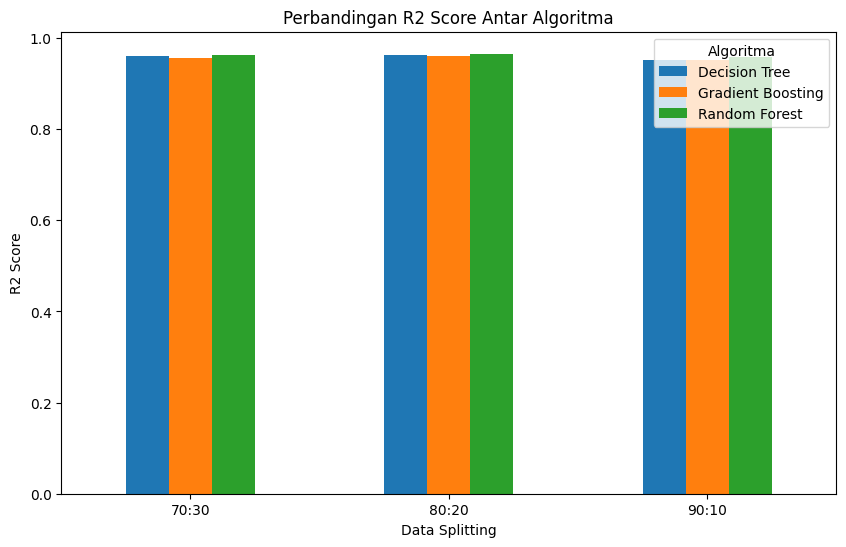

In [573]:
# =========================================
# Visualisasi R2 Score
# =========================================

pivot_r2 = comparison_table.pivot(
    index="Split Data",
    columns="Algoritma",
    values="R2 Score"
)

pivot_r2.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan R2 Score Antar Algoritma")

plt.ylabel("R2 Score")

plt.xlabel("Data Splitting")

plt.xticks(rotation=0)

plt.legend(title="Algoritma")

plt.show()

In [574]:
# =========================================
# Menentukan Model Terbaik
# =========================================

best_model = comparison_table.sort_values(
    by=["R2 Score", "RMSE"],
    ascending=[False, True]
).head(1)

best_model

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
1,Random Forest,80:20,0.017798,0.008681,0.09317,0.965277


In [575]:
# =========================================
# Mengambil Informasi Model Terbaik
# =========================================

best_algorithm = best_model.iloc[0]["Algoritma"]

best_split = best_model.iloc[0]["Split Data"]

print("Algoritma Terbaik :", best_algorithm)

print("Rasio Data :", best_split)

Algoritma Terbaik : Random Forest
Rasio Data : 80:20


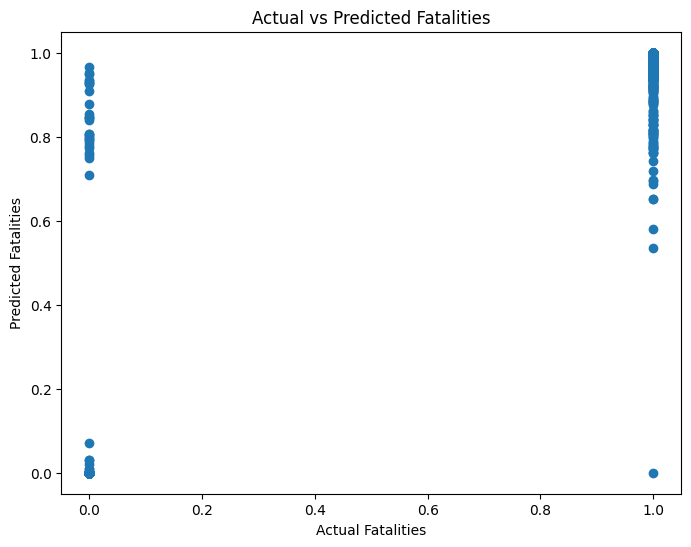

In [576]:
# =========================================
# Scatter Plot Model Terbaik
# =========================================

best_predictions = rf_grid_90.best_estimator_.predict(
    X_test_90
)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_90,
    best_predictions
)

plt.xlabel("Actual Fatalities")

plt.ylabel("Predicted Fatalities")

plt.title("Actual vs Predicted Fatalities")

plt.show()

In [577]:
# =========================================
# Analisis Data Splitting
# =========================================

comparison_table.groupby(
    "Split Data"
)[["RMSE", "R2 Score"]].mean()

,RMSE,R2 Score
Split Data,,
70:30,0.100291,0.959771
80:20,0.096252,0.962911
90:10,0.107415,0.953776


In [578]:
# =========================================
# Model Terbaik Tiap Split
# =========================================

comparison_table.loc[
    comparison_table.groupby(
        "Split Data"
    )["R2 Score"].idxmax()
]

,Algoritma,Split Data,MAE,MSE,RMSE,R2 Score
0,Random Forest,70:30,0.017929,0.009517,0.097557,0.961973
1,Random Forest,80:20,0.017798,0.008681,0.093170,0.965277
2,Random Forest,90:10,0.019945,0.010570,0.102810,0.957693


# Analisis Hasil Model Comparison

Berdasarkan hasil perbandingan model yang telah dilakukan, seluruh algoritma berhasil dibandingkan menggunakan berbagai variasi data splitting.

Perbandingan dilakukan terhadap:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

dengan rasio data:

1. 70:30
2. 80:20
3. 90:10

Hasil evaluasi menunjukkan bahwa model dengan nilai R² Score tertinggi dan RMSE terkecil memiliki performa prediksi terbaik.

Visualisasi bar chart menunjukkan perbandingan performa antar algoritma pada setiap rasio data splitting.

Scatter plot digunakan untuk mengevaluasi kualitas prediksi model terbaik dengan membandingkan nilai aktual dan hasil prediksi model.

Semakin dekat titik-titik scatter plot terhadap garis diagonal, maka semakin baik kemampuan prediksi model.

Analisis data splitting dilakukan untuk melihat stabilitas performa model ketika jumlah data training ditingkatkan.

Jika nilai RMSE semakin kecil dan R² Score semakin tinggi pada rasio 90:10, maka hal tersebut menunjukkan bahwa penambahan data training membantu meningkatkan performa model.

# Kesimpulan Tahap Model Comparison

Berdasarkan hasil perbandingan seluruh model, berhasil dilakukan evaluasi terhadap 9 kombinasi model regression menggunakan:

1. Random Forest Regression
2. Decision Tree Regression
3. Gradient Boosting Regression

dengan berbagai variasi data splitting.

Evaluasi dilakukan menggunakan:

1. MAE
2. MSE
3. RMSE
4. R² Score

Model terbaik ditentukan berdasarkan:

- R² Score tertinggi
- RMSE terkecil

Hasil akhir dari tahap ini menunjukkan algoritma yang paling optimal dalam memprediksi jumlah kematian (`Fatalities`) berdasarkan fitur-fitur yang digunakan.

Model terbaik yang diperoleh dari tahap ini dapat digunakan sebagai model final untuk implementasi prediksi pada data baru.